Cause and Effect

A -> B


In [110]:
import matplotlib.pyplot as plt
import pandas as pd
from fredapi import Fred

FRED_API_KEY = "612c90fb30af12767bbcaf9513bac5ed"
fred = Fred(api_key=FRED_API_KEY)


In [111]:
def plot_it(data: pd.Series, title: str, figsize: tuple[int, int] = (15, 5)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(data)
    ax.grid(True, which="both")
    plt.title(title)


Federal Funds Effective Rate Rising: True


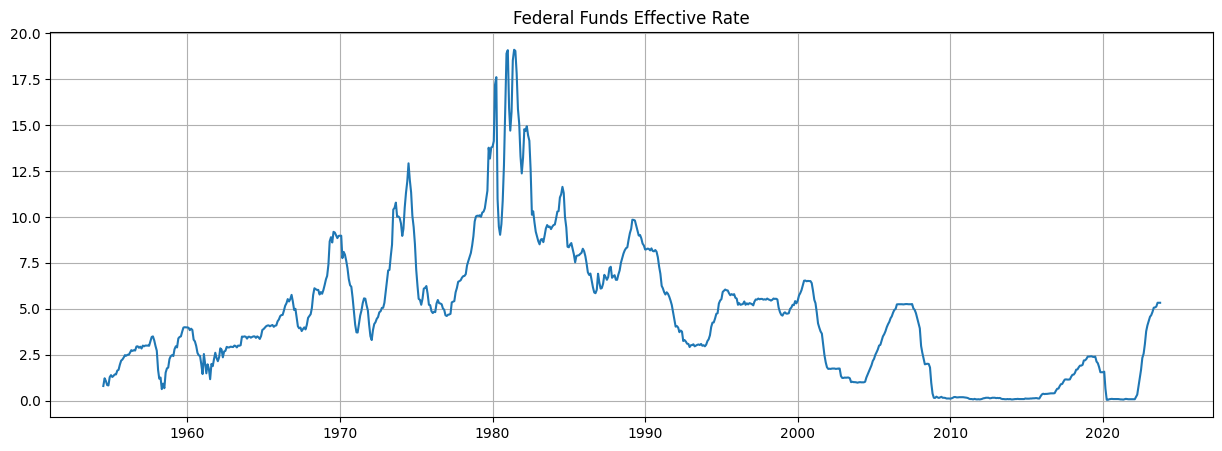

In [112]:
def federal_funds_rising():
    """Federal Funds Effective Rate (FEDFUNDS)"""
    data = fred.get_series("FEDFUNDS")
    plot_it(data, "Federal Funds Effective Rate")
    return data.iloc[-1] > data.iloc[-4]


ffr = federal_funds_rising()
print(f"Federal Funds Effective Rate Rising: {ffr}")


Real GDP Contraction: False


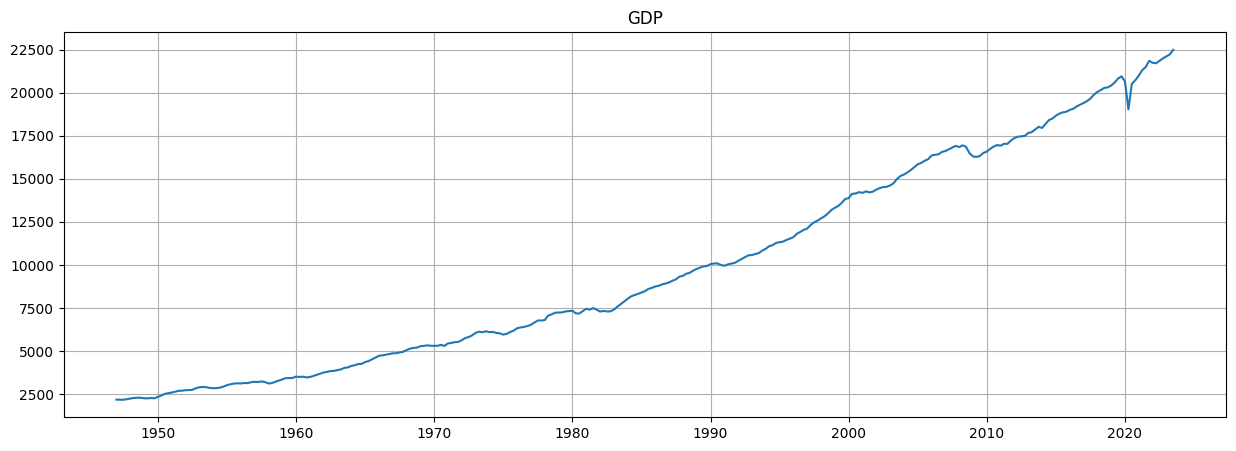

In [113]:
def real_gdp_contraction() -> bool:
    """
    GDP Contraction: One of the primary indicators is a decline in Gross Domestic Product (GDP),
    which measures the total value of goods and services produced in a country.
    A negative GDP growth for two consecutive quarters is often considered a technical recession.
    """
    # Real Gross Domestic Product (GDPC1)
    data = fred.get_series("GDPC1")
    plot_it(data, "GDP")
    return data.iloc[-1] < data.iloc[-12]


gdp_contr = real_gdp_contraction()
print(f"Real GDP Contraction: {gdp_contr}")


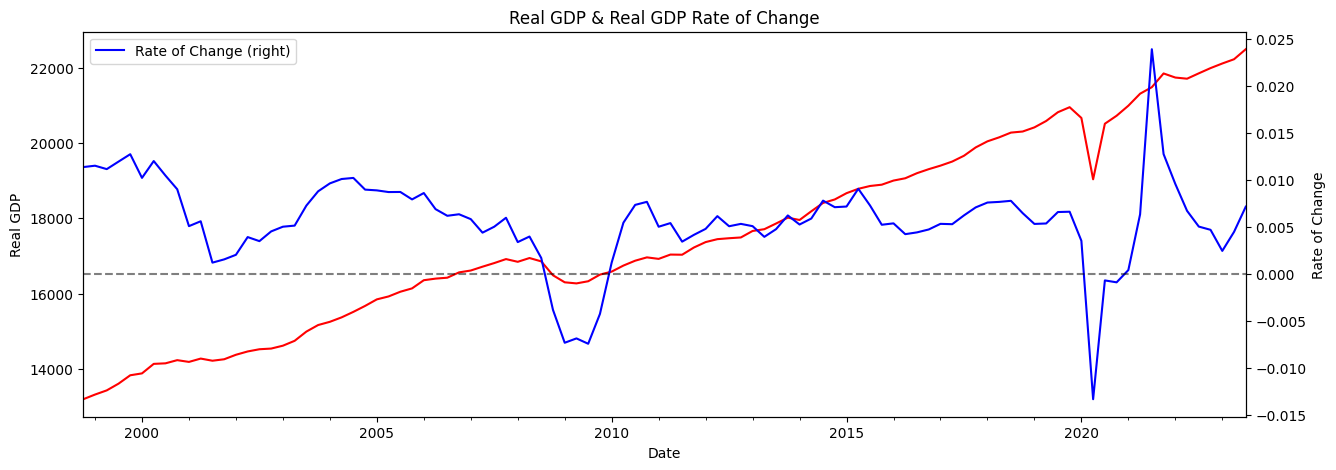

In [143]:
def gdp_rate_of_change():
    gdp = fred.get_series("GDPC1")
    rolling_avg = gdp.rolling(window=5).mean()
    rate_of_change = rolling_avg.pct_change()
    return gdp.dropna(), rate_of_change.dropna()


ONE_YEAR = -5
FIVE_YEARS = -25
TWENTY_YEARS = -100
gdp, gdp_roc = gdp_rate_of_change()
gdp, gdp_roc = gdp[TWENTY_YEARS:], gdp_roc[TWENTY_YEARS:]

plt.figure(figsize=(15, 5))
ax1 = gdp_roc.plot(label="Rate of Change", color="blue", secondary_y=True)
ax2 = gdp.plot(label="Real GDP", color="red")

# draw a horizontal line at 0.0 for the rate of change
ax1.axhline(y=0, color="black", alpha=0.5, linestyle="--")
ax1.set_ylabel("Rate of Change")
ax1.set_xlabel("Date")

ax2.set_ylabel("Real GDP")
ax2.set_xlabel("Date")

plt.title("Real GDP & Real GDP Rate of Change")
plt.legend(loc="upper left")
plt.show()


Rising Unemployment: True


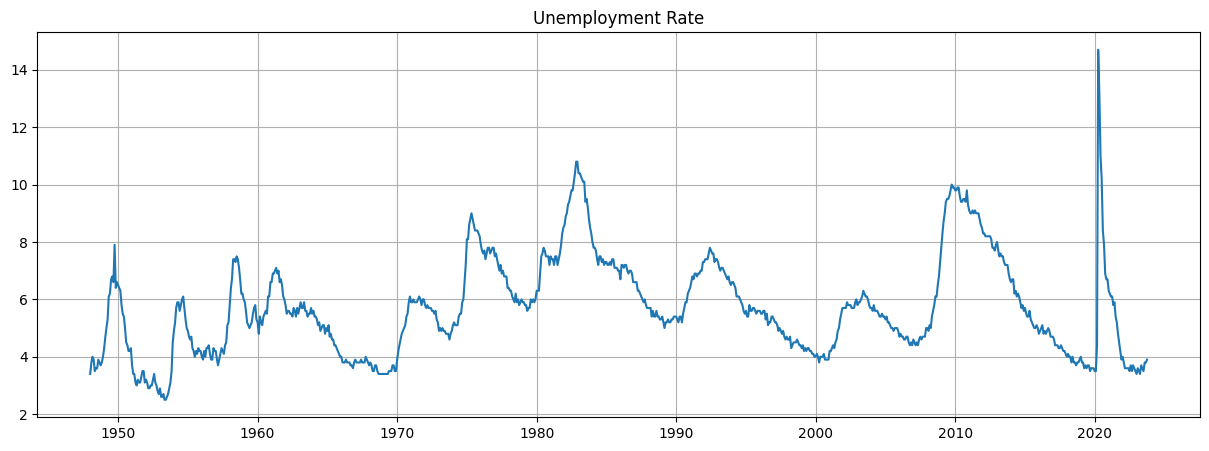

In [115]:
def rising_unemployment() -> bool:
    """
    Rising Unemployment: Job losses and rising unemployment rates are common
    during a recession as businesses may cut costs by reducing their workforce.
    """

    data = fred.get_series("UNRATE")
    result = data.dropna()
    plot_it(result, "Unemployment Rate", figsize=(15, 5))
    return result.iloc[-12] < result.iloc[-1]


rising_unemp = rising_unemployment()
print(f"Rising Unemployment: {rising_unemp}")


Consumer Spending: False


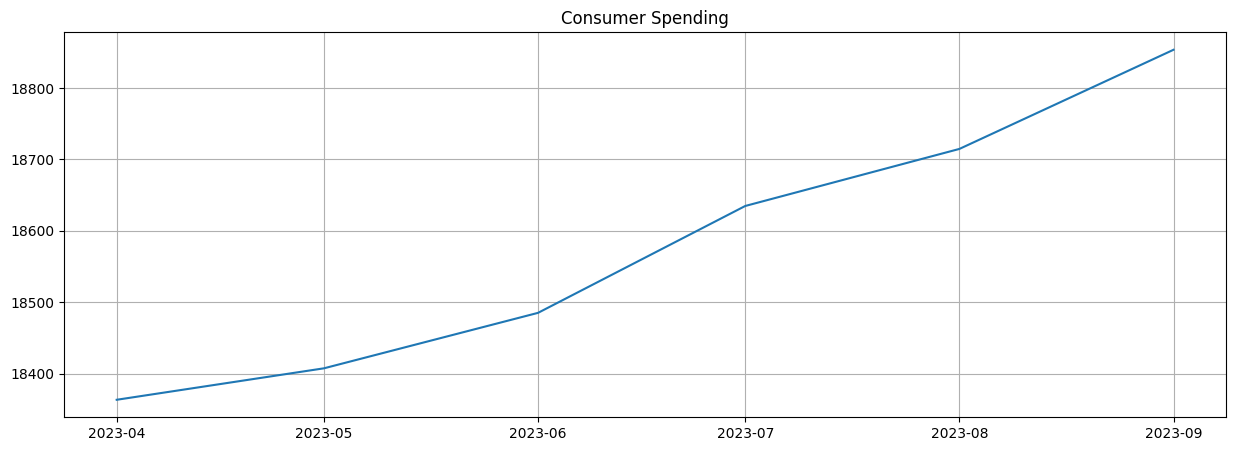

In [116]:
def consumer_spending_decline() -> bool:
    """
    Decline in Consumer Spending: Consumer spending tends to decrease during economic
    downturns as people become more cautious about their finances.
    This can impact various industries, especially retail.
    """
    data = fred.get_series("PCE")
    result = data.dropna()
    plot_it(result[-6:], "Consumer Spending", figsize=(15, 5))
    return result.iloc[-6] > result.iloc[-1]


cons_spd_dec = consumer_spending_decline()
print(f"Consumer Spending: {cons_spd_dec}")


Decline in Industrial Production: True


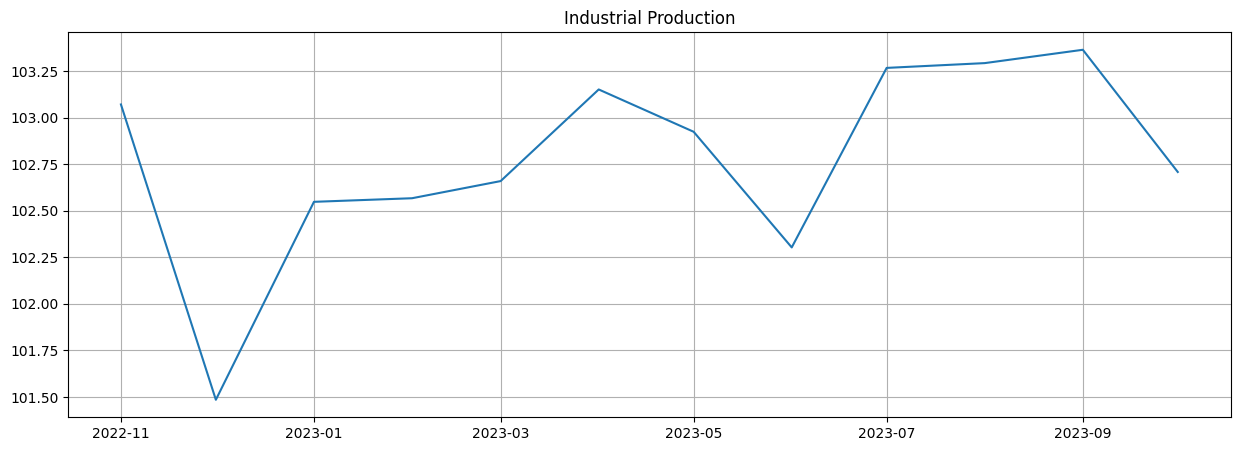

In [117]:
def industrial_production_decline() -> bool:
    """
    Reduced Industrial Production: A decrease in the production of goods and services
    by industries is a clear sign of economic contraction.
    This can be measured by the Industrial Production Index.
    """
    data = fred.get_series("INDPRO")
    result = data.dropna()
    plot_it(result[-12:], "Industrial Production")
    return result.iloc[-12] > result.iloc[-1]


ipd = industrial_production_decline()
print(f"Decline in Industrial Production: {ipd}")


Decline in Stock Market: False


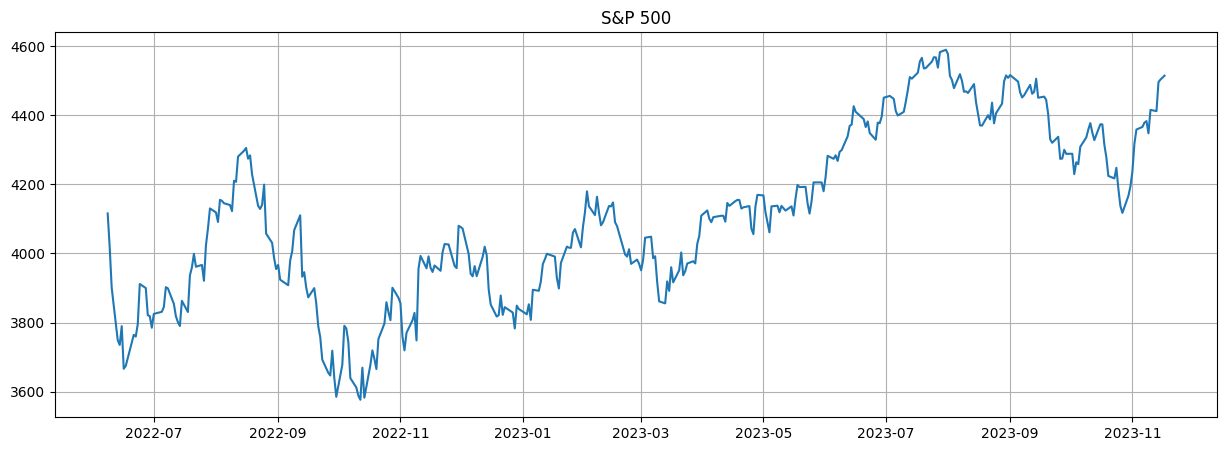

In [118]:
def stock_market_decline() -> bool:
    """
    Stock Market Decline: Stock markets are sensitive to economic conditions.
    A prolonged period of declining stock prices may indicate investor pessimism about the economic outlook.
    """
    data = fred.get_series("SP500")
    result = data.dropna()
    ONE_YEAR = -365
    plot_it(result[ONE_YEAR:], f"S&P 500")
    return result.iloc[ONE_YEAR] > result.iloc[-1]


smd = stock_market_decline()
print(f"Decline in Stock Market: {smd}")


Housing Market Slowdown: False


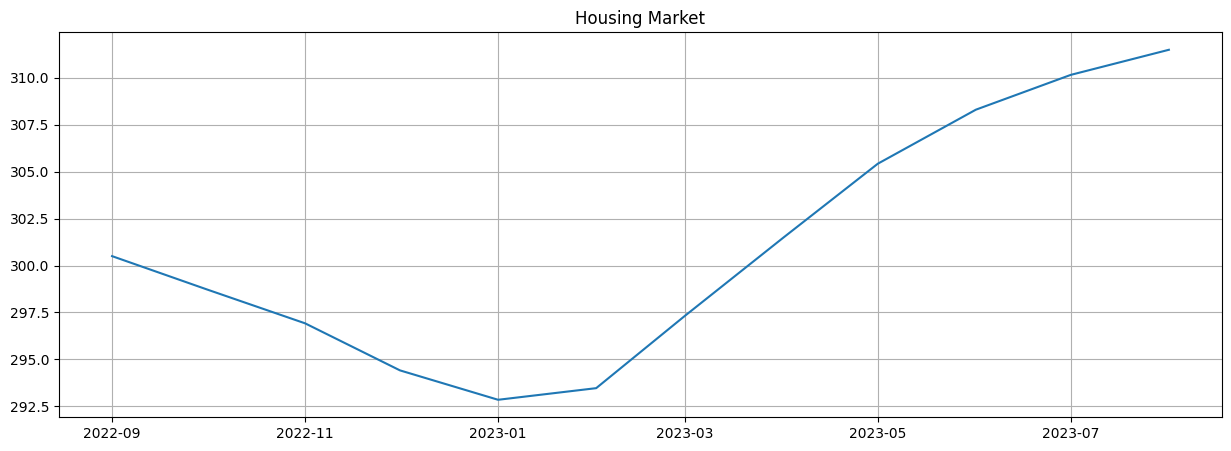

In [119]:
def housing_market_decline() -> bool:
    """
    Housing Market Slowdown: A recession often leads to a slowdown in the real estate market,
    with declining home sales, falling prices, and increased foreclosures.
    """

    data = fred.get_series("CSUSHPINSA")
    result = data.dropna()
    plot_it(result[-12:], "Housing Market")
    return result.iloc[-12] > result.iloc[-1]


hmd = housing_market_decline()
print(f"Housing Market Slowdown: {hmd}")


Tightening Credit Conditions: True


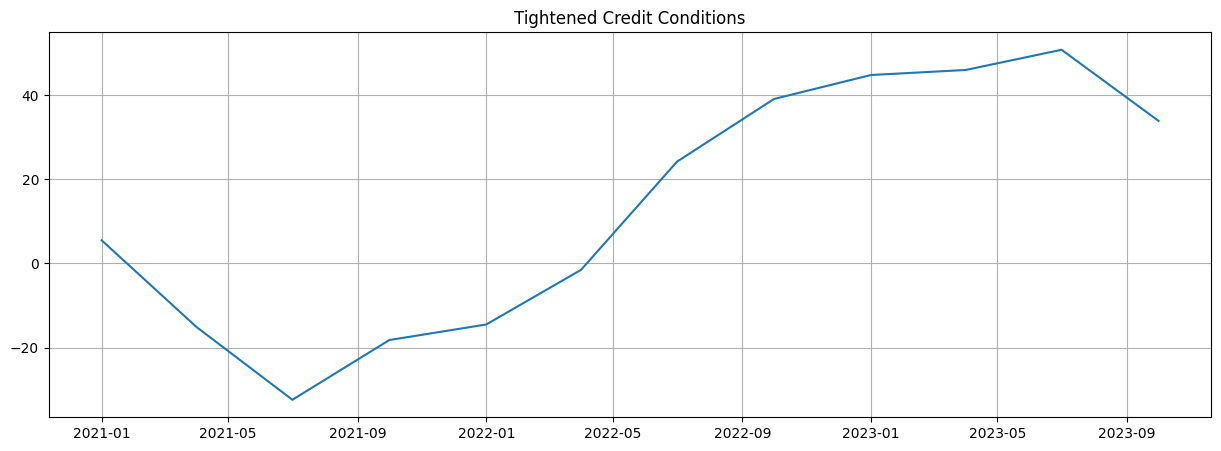

In [120]:
def tightened_credit_conditions() -> bool:
    """
    Tightened Credit Conditions: Banks may become more cautious about lending during economic downturns,
    leading to tightened credit conditions and reduced access to loans for businesses and consumers.
    """
    data = fred.get_series("DRTSCILM")
    result = data.dropna()
    plot_it(result[-12:], "Tightened Credit Conditions")
    return result.iloc[-1] > result.iloc[-12]


tcc = tightened_credit_conditions()
print(f"Tightening Credit Conditions: {tcc}")


Inverted Yield Curve 10Y - 2Y: True


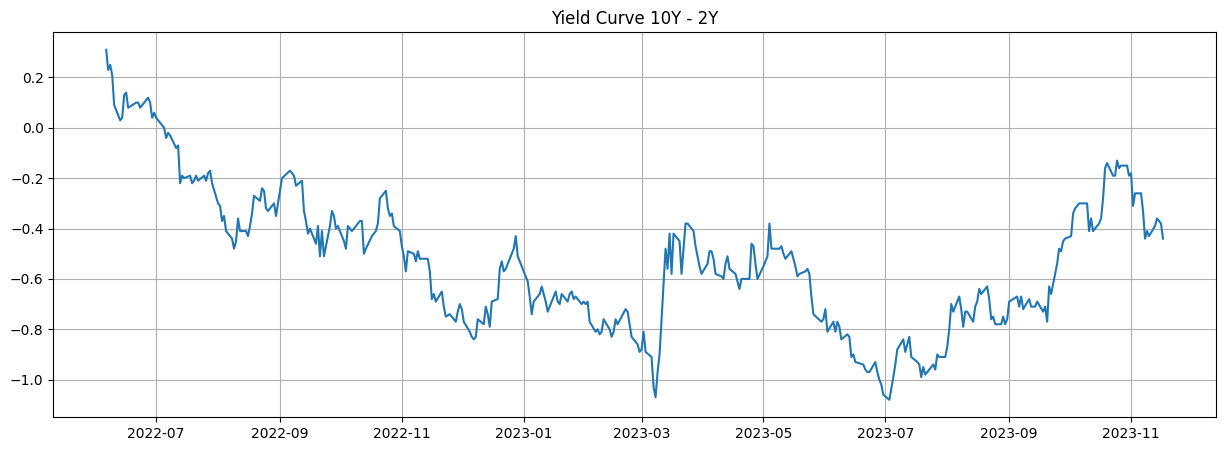

In [121]:
def inverted_yield_curve_10y_2y() -> bool:
    """
    Inverted Yield Curve: An inverted yield curve, where short-term interest rates are higher
    than long-term rates has historically been a reliable predictor of economic recessions.
    """
    ONE_YEAR = -365
    data = fred.get_series("T10Y2Y")
    data_clean = data.dropna()
    resultList = [value for value in data_clean[ONE_YEAR:-1] if value < 0]

    plot_it(data_clean[ONE_YEAR:], "Yield Curve 10Y - 2Y")
    return any(resultList)


iyc = inverted_yield_curve_10y_2y()
print(f"Inverted Yield Curve 10Y - 2Y: {iyc}")


Inverted Yield Curve 10Y - 3M: True


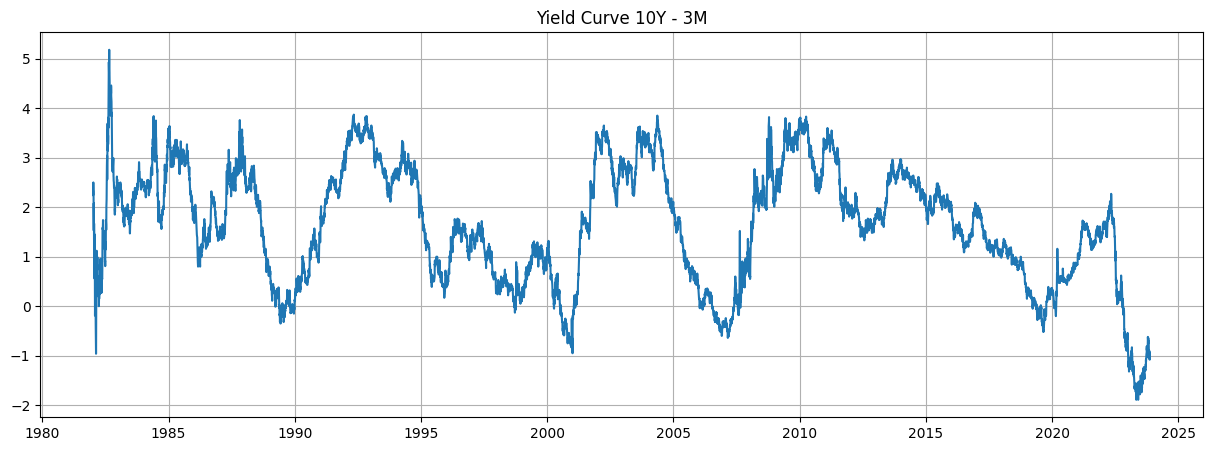

In [122]:
def inverted_yield_curve_10y_3m() -> bool:
    """10-Year Treasury Constant Maturity Minus 3-Month Treasury Constant Maturity (T10Y3M)"""
    ONE_YEAR = -365
    data = fred.get_series("T10Y3M")
    data_clean = data.dropna()
    resultList = [value for value in data_clean[ONE_YEAR:-1] if value < 0]
    plot_it(data_clean, "Yield Curve 10Y - 3M")
    return any(resultList)


iyc2 = inverted_yield_curve_10y_3m()
print(f"Inverted Yield Curve 10Y - 3M: {iyc2}")


Business Investment Decline: False


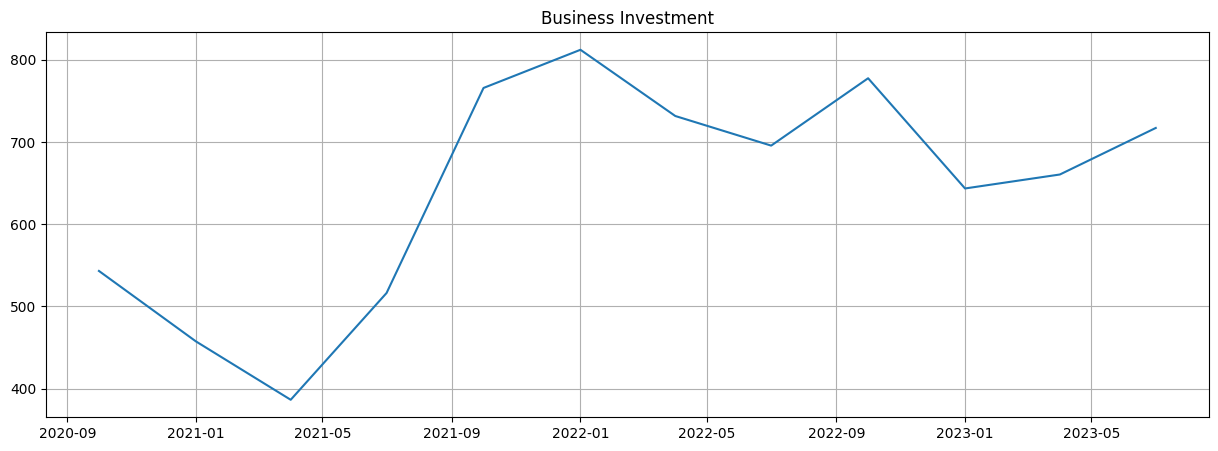

In [123]:
def business_investment_decline() -> bool:
    """
    Business Investment Decline: Companies may cut back on investments during a recession,
    leading to a decline in capital expenditures and business expansion.
    """
    data = fred.get_series("W790RC1Q027SBEA")
    result = data.dropna()
    plot_it(result[-12:], "Business Investment")
    return result.iloc[-12] > result.iloc[-1]


bid = business_investment_decline()
print(f"Business Investment Decline: {bid}")


Truck Transportation Employee Decline: True


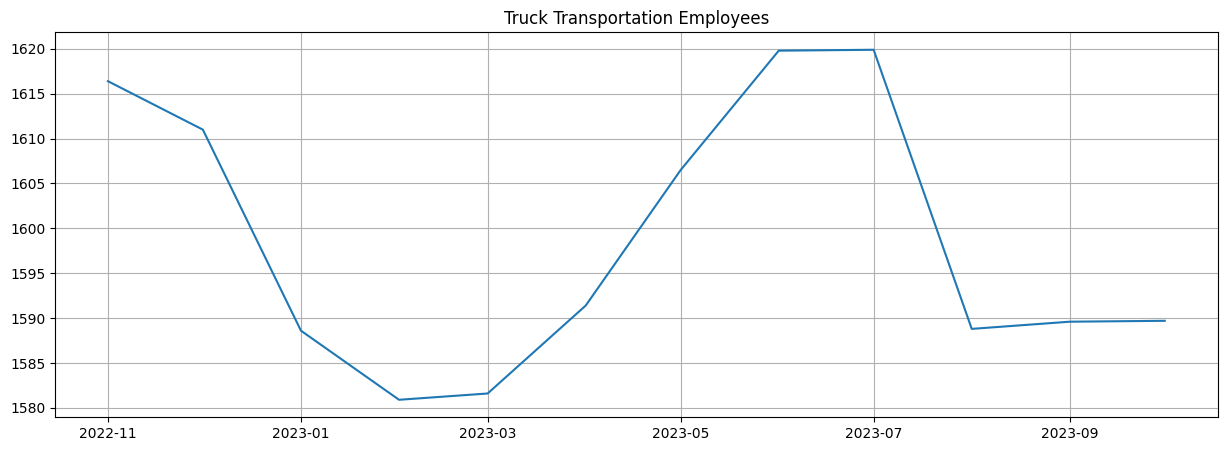

In [124]:
def truck_transportation_employee_decline() -> bool:
    data = fred.get_series("CEU4348400001")
    result = data.dropna()
    plot_it(result[-12:], "Truck Transportation Employees")
    return result.iloc[-12] > result.iloc[-1]


tted = truck_transportation_employee_decline()
print(f"Truck Transportation Employee Decline: {tted}")


Increase in Credit Card Delinquency: True


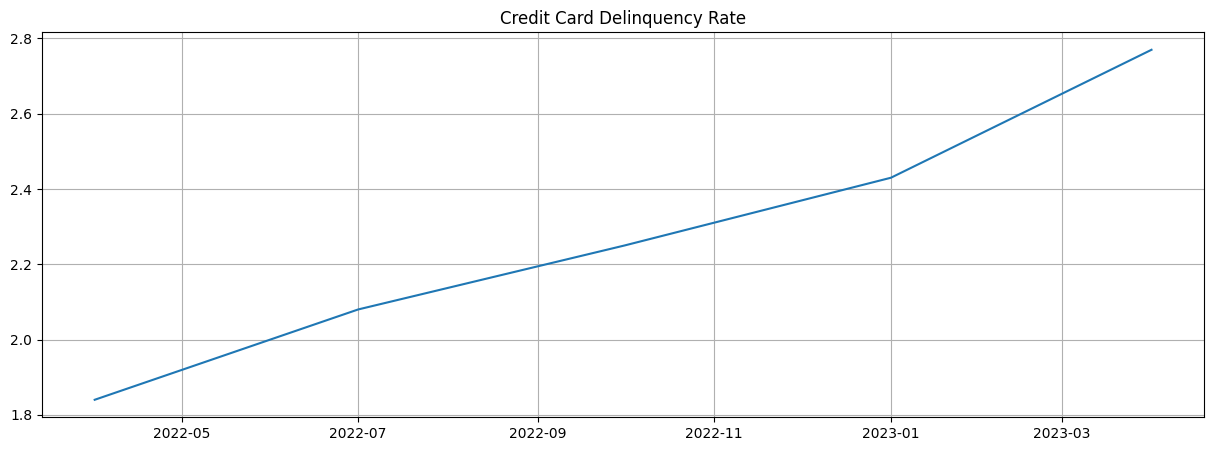

In [125]:
def credit_card_delinquency_increase() -> bool:
    """Delinquency Rate on Credit Card Loans, All Commercial Banks"""
    data = fred.get_series("DRCCLACBS")
    result = data.dropna()
    plot_it(result[-5:], "Credit Card Delinquency Rate")
    return result.iloc[-1] > result.iloc[-5]


ccdi = credit_card_delinquency_increase()
print(f"Increase in Credit Card Delinquency: {ccdi}")


Decline in Job Openings: True


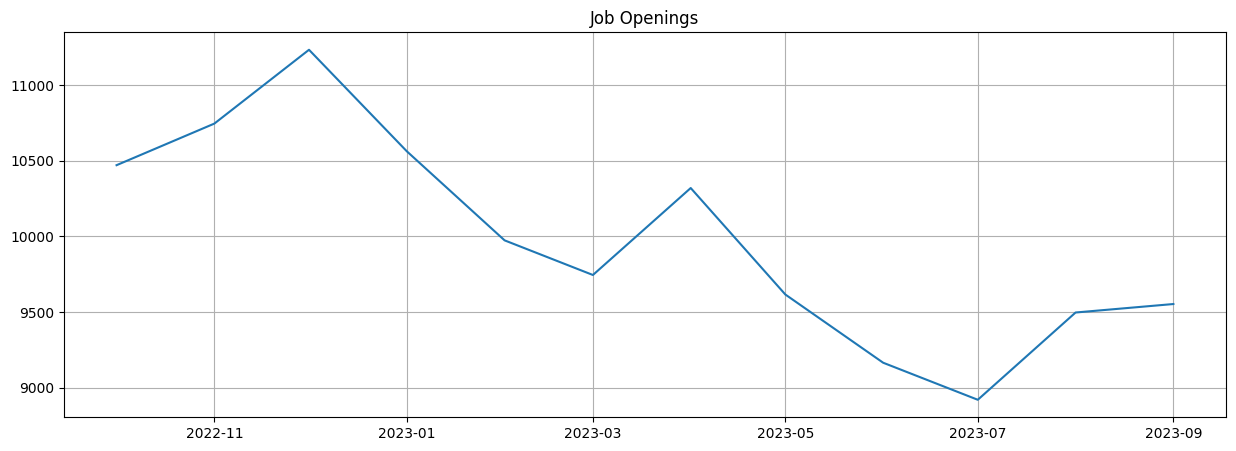

In [126]:
def job_openings() -> bool:
    data = fred.get_series("JTSJOL")
    result = data.dropna()
    plot_it(result[-12:], "Job Openings")
    return result.iloc[-1] > result.iloc[-12]


jo = job_openings()
print(f"Decline in Job Openings: {ccdi}")


Large Bank Consumer Credit Card Balances: Total Balances: True


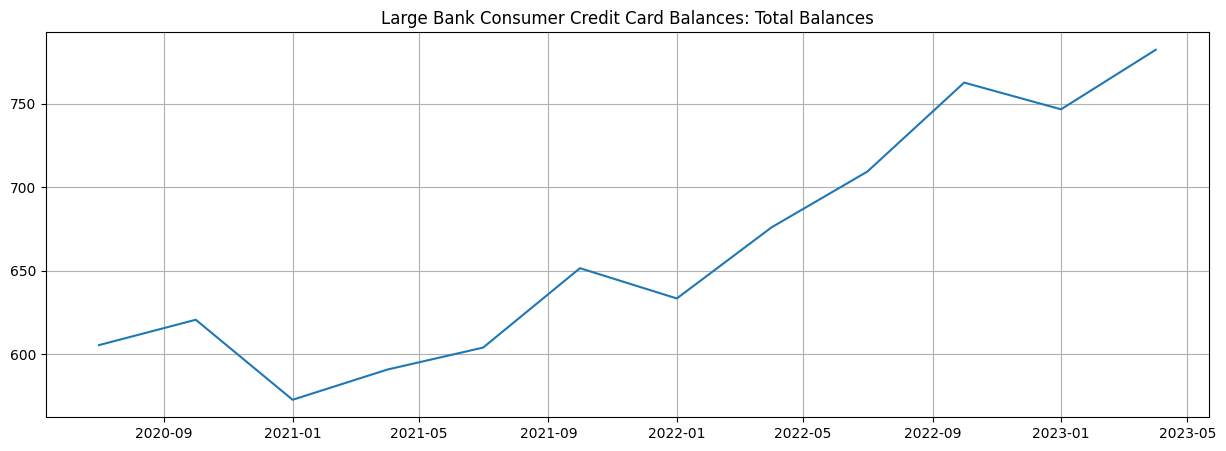

In [127]:
def total_credit_card_balances() -> bool:
    """Large Bank Consumer Credit Card Balances: Total Balances (RCCCBBALTOT)"""
    data = fred.get_series("RCCCBBALTOT")
    result = data.dropna()
    plot_it(result[-12:], "Large Bank Consumer Credit Card Balances: Total Balances")
    return result.iloc[-1] > result.iloc[-12]


tccb = total_credit_card_balances()
print(f"Large Bank Consumer Credit Card Balances: Total Balances: {tccb}")


Commercial Bank Interest Rate on Credit Card Plans: True


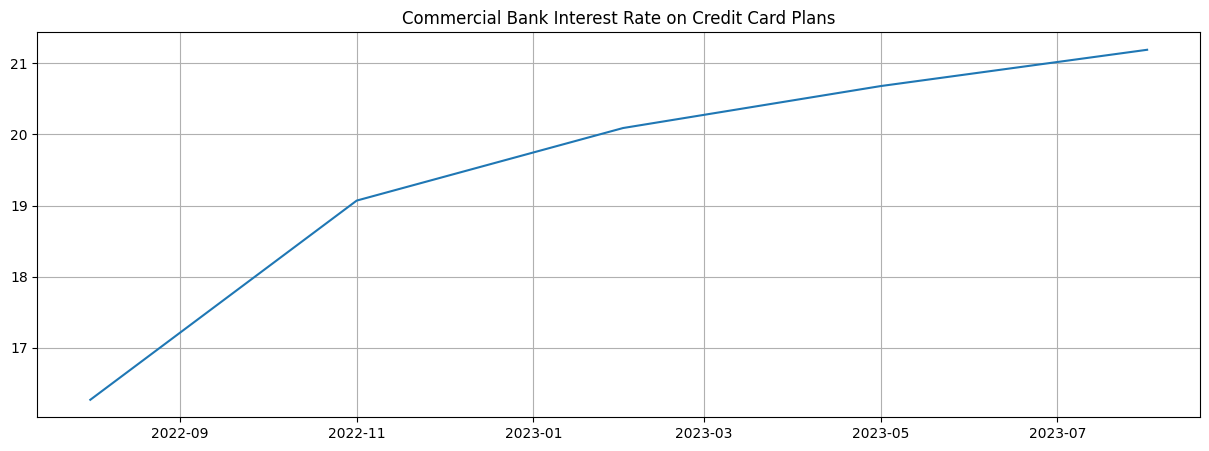

In [128]:
# Commercial Bank Interest Rate on Credit Card Plans, All Accounts (TERMCBCCALLNS)
def commercial_bank_interest_rate_on_credit_card_plans() -> bool:
    data = fred.get_series("TERMCBCCALLNS")
    result = data.dropna()
    plot_it(result[-5:], "Commercial Bank Interest Rate on Credit Card Plans")
    return result.iloc[-1] > result.iloc[-5]


cbirccp = commercial_bank_interest_rate_on_credit_card_plans()
print(f"Commercial Bank Interest Rate on Credit Card Plans: {cbirccp}")


Personal interest payments: True


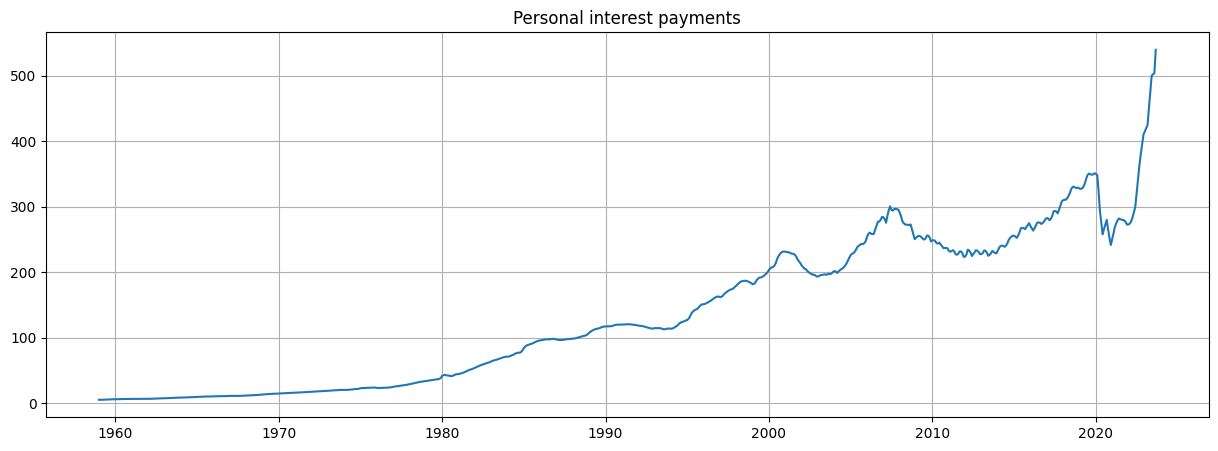

In [129]:
#  Personal interest payments (B069RC1)
def personal_interest_payments():
    data = fred.get_series("B069RC1")
    result = data.dropna()
    plot_it(result, "Personal interest payments")
    return result.iloc[-1] > result.iloc[-12]


pip = personal_interest_payments()
print(f"Personal interest payments: {pip}")


In [130]:
results = [
    gdp_contr,
    rising_unemp,
    cons_spd_dec,
    ipd,
    smd,
    hmd,
    tcc,
    iyc,
    bid,
    tted,
    ccdi,
    iyc2,
    jo,
    tccb,
    cbirccp,
    pip,
]

print(f"Indicators Result: {results.count(True)}/{len(results)}")


Indicators Result: 10/16


Other Indicators to Consider
- Net interest and miscellaneous payments on assets
- Personal Savings Rate

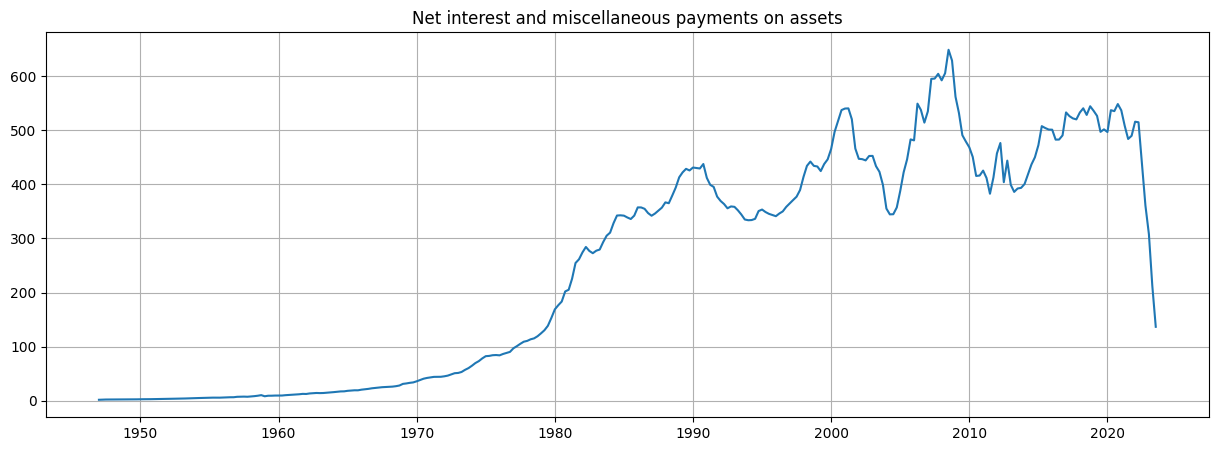

In [131]:
#  Net interest and miscellaneous payments on assets (W255RC1Q027SBEA)
data = fred.get_series("W255RC1Q027SBEA")
result = data.dropna()
plot_it(result, "Net interest and miscellaneous payments on assets")


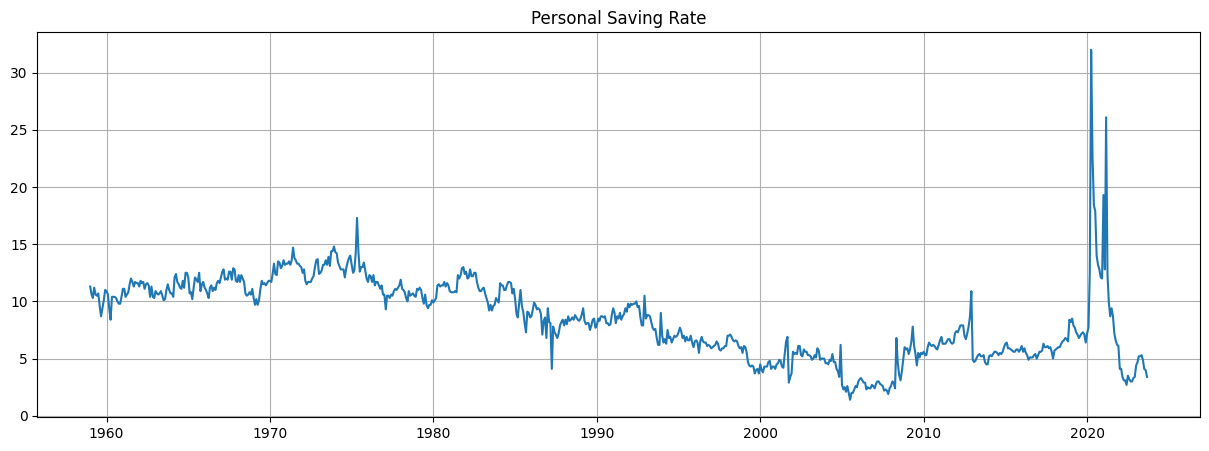

In [132]:
#  Personal Saving Rate (PSAVERT)
data = fred.get_series("PSAVERT")
result = data.dropna()
plot_it(result, "Personal Saving Rate")


In [133]:
#  Net saving as a percentage of gross national income (W207RC1Q156SBEA)


In [134]:
# LOOK AT THESE STOCKS
# In addition, certain individual stocks have outperformed during each of the past two U.S. recessions.
# Walmart Inc. (ticker: WMT), Abbott Laboratories (ABT) and Home Depot Inc. (HD)
# are just three examples of stocks that beat the S&P 500 in both 2008 and 2020.
